In [56]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader, Subset
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [57]:
model = CNN(width=6, bn=True, normalise=False)
device = torch.device("mps")
results_dir = TRAINING_RESULTS / 'ext_high_mass' / 'good_runs' /'run_210626_163120'
weights_path = results_dir /'best_model_weights.pth'
#weights_path = results_dir / 'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

CNN(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=12288, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

In [58]:
file_path = sep_ehm_dataset_path

with h5py.File(file_path, 'r') as h5:
    images = h5['QT'][:]
    seps = h5['sep'][:]

images = np.squeeze(images, axis=1)

In [59]:
gw_mean, glitch_mean = [], []
gw_p5, glitch_p5 = [], []
gw_p95, glitch_p95 = [], []
all_probs = []

with torch.no_grad():
    for sep in np.unique(seps):
        same_sep = torch.tensor(images[seps == sep],\
                                dtype=torch.float32).permute(0, 3, 1, 2).contiguous()
        
        output = model(same_sep.to(device=device))
        probs = torch.sigmoid(output)
        all_probs.append(probs.to('cpu').numpy())

        gw_probs = probs[:, 0].to('cpu').numpy()
        glitch_probs = probs[:, 1].to('cpu').numpy()

        gw_mean.append(np.mean(gw_probs))
        glitch_mean.append(np.mean(glitch_probs))

        gw_p5.append(np.percentile(gw_probs, 10))
        gw_p95.append(np.percentile(gw_probs, 90))

        glitch_p5.append(np.percentile(glitch_probs, 10))
        glitch_p95.append(np.percentile(glitch_probs, 90))

gw_mean = np.array(gw_mean)
glitch_mean = np.array(glitch_mean)

gw_p5 = np.array(gw_p5)
gw_p95 = np.array(gw_p95)

glitch_p5 = np.array(glitch_p5)
glitch_p95 = np.array(glitch_p95)

gw_err = [gw_mean - gw_p5, gw_p95 - gw_mean]
glitch_err = [glitch_mean - glitch_p5, glitch_p95 - glitch_mean]

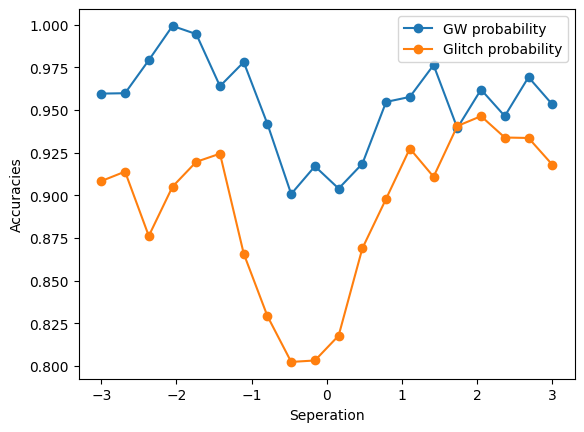

In [60]:
#plt.errorbar(np.unique(seps), gw_mean, yerr=gw_err, fmt='-o', label='GW Probability')
#plt.errorbar(np.unique(seps), glitch_mean, yerr=glitch_err, fmt='-o', label='Glitch Probability')

plt.plot(2*np.unique(seps), gw_mean, marker='o', label='GW probability')
plt.plot(2*np.unique(seps), glitch_mean, marker='o', label='Glitch probability')
plt.xlabel('Seperation')
plt.ylabel('Accuracies')
plt.legend()
plt.show()

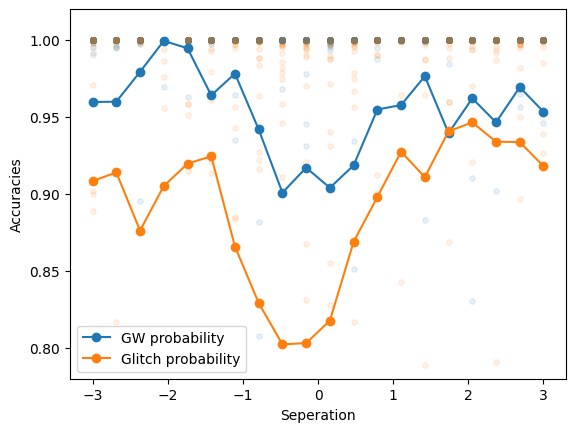

In [55]:
gw = all_probs[:, :, 0]
glitch = all_probs[:, :, 1]

gw_median = np.median(gw, axis=1)
glitch_median = np.median(glitch, axis=1)

for i in range(gw.shape[1]):
    plt.scatter(2*np.unique(seps), gw[:, i], s=15, alpha=0.1, color='C0')
    plt.scatter(2*np.unique(seps), glitch[:, i], s=15, alpha=0.1, color='C1')

plt.plot(2*np.unique(seps), gw_mean, marker='o', label='GW probability')
plt.plot(2*np.unique(seps), glitch_mean, marker='o', label='Glitch probability')
plt.xlabel('Seperation')
plt.ylabel('Accuracies')
plt.ylim(0.78, 1.02)
plt.legend()
plt.show()

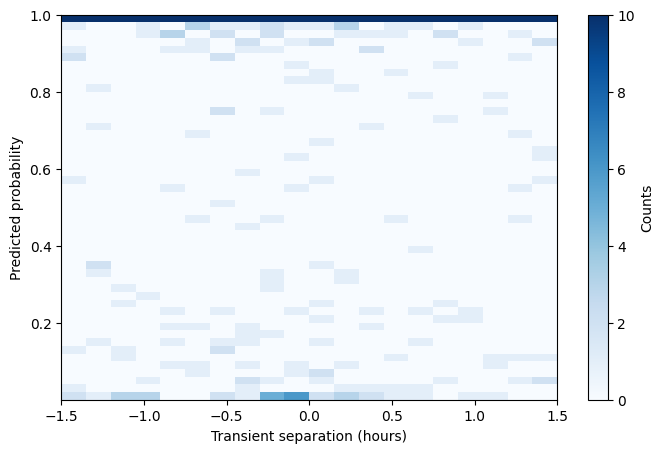

In [43]:
from matplotlib.colors import LogNorm
seps_unique = np.unique(seps)

x = np.repeat(seps_unique, all_probs.shape[1])   # (1000,)
y = all_probs[:,:,1].ravel()                            # (1000,)

plt.figure(figsize=(8,5))

plt.hist2d(
    x,
    y,
    bins=[20, 50],          # 20 x-bins, 50 y-bins
    cmap="Blues"
)

plt.clim(0, 10)
plt.colorbar(label="Counts")
plt.xlabel("Transient separation (hours)")
plt.ylabel("Predicted probability")

plt.show()